In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv('/mnt/data/traffic.csv')

print(df.head())
print(df.info())

# =========================
# 3. BASIC PREPROCESSING
# =========================
# Convert datetime if exists
if 'DateTime' in df.columns:
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df['hour'] = df['DateTime'].dt.hour
    df['day'] = df['DateTime'].dt.day
    df['month'] = df['DateTime'].dt.month

# Drop missing
df = df.dropna()

# =========================
# 4. EDA PLOT (BOXPLOT)
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.title('Vehicles Distribution by Junction')
plt.show()

# =========================
# 5. FEATURE SELECTION
# =========================
features = ['Junction', 'hour', 'day', 'month']
features = [f for f in features if f in df.columns]

X = df[features]
y = df['Vehicles']

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 7. MODELS
# =========================
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

# =========================
# 8. TRAIN + EVALUATE
# =========================
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

# =========================
# 9. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, columns=["model", "mae", "rmse", "r2"])
print("\nModel Comparison:\n")
print(results_df)

# =========================
# 10. BEST MODEL (Random Forest usually)
# =========================
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# =========================
# 11. ANOMALY DETECTION
# =========================
residuals = np.abs(y_test - y_pred)

threshold = np.percentile(residuals, 95)
anomalies = residuals > threshold

# =========================
# 12. PLOT ACTUAL vs PREDICTED
# =========================
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual", alpha=0.7)
plt.plot(y_pred, label="Predicted", alpha=0.7)

# Highlight anomalies
plt.scatter(
    np.where(anomalies),
    y_test.values[anomalies],
    color='red',
    label='Anomalies'
)

plt.title("Actual vs Predicted with Anomalies")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/traffic.csv'

In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'traffic.csv', 'week 3 code.ipynb']


Columns: Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')
              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
Target: Vehicles
Junction: Junction
Datetime: DateTime


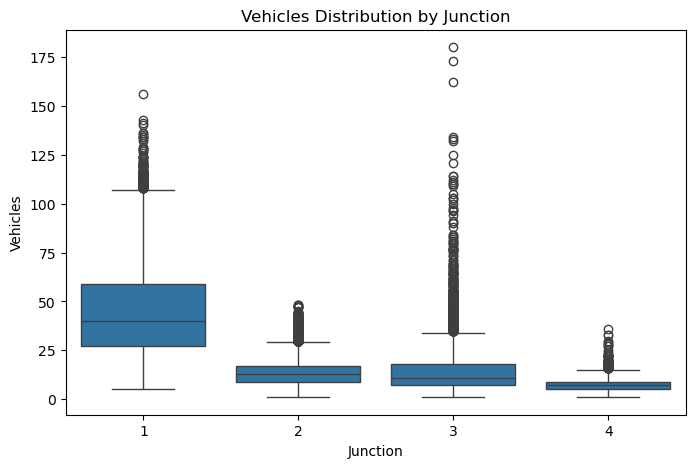


Model Comparison:

               Model        MAE       RMSE        R2
0      Decision Tree  12.221893  19.197659  0.095686
1      Random Forest  10.118193  15.754862  0.390952
2  Linear Regression  11.173237  15.135451  0.437900
3                SVR   9.723995  15.587852  0.403796
4                KNN   9.558375  14.120031  0.510792


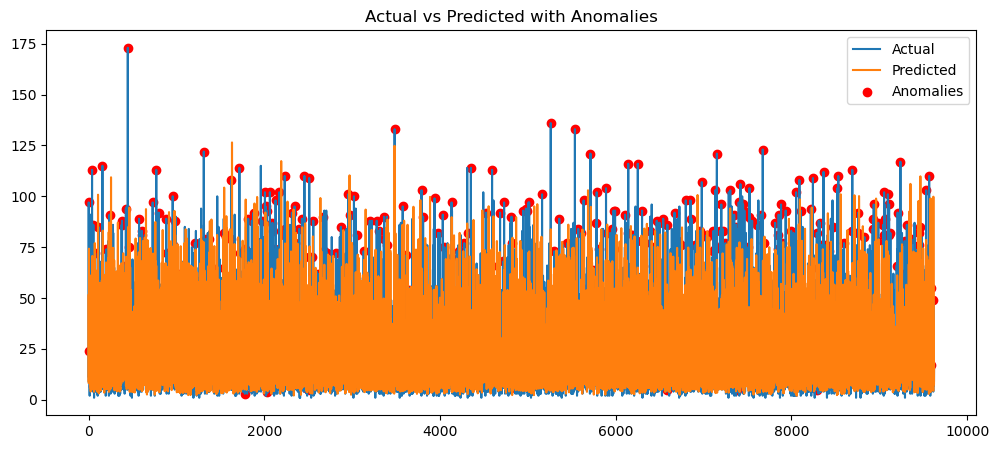

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# =========================
# 2. LOAD DATA (FIXED PATH)
# =========================
df = pd.read_csv('traffic.csv')

print("Columns:", df.columns)
print(df.head())

# =========================
# 3. AUTO DETECT COLUMNS
# =========================
target_col = None
junction_col = None
datetime_col = None

for col in df.columns:
    if 'vehicle' in col.lower():
        target_col = col
    if 'junction' in col.lower():
        junction_col = col
    if 'date' in col.lower():
        datetime_col = col

print("Target:", target_col)
print("Junction:", junction_col)
print("Datetime:", datetime_col)

# =========================
# 4. PREPROCESSING
# =========================
if datetime_col:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
    df['hour'] = df[datetime_col].dt.hour
    df['day'] = df[datetime_col].dt.day
    df['month'] = df[datetime_col].dt.month

df = df.dropna()

# =========================
# 5. EDA PLOT
# =========================
if junction_col and target_col:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=junction_col, y=target_col, data=df)
    plt.title("Vehicles Distribution by Junction")
    plt.show()

# =========================
# 6. FEATURES
# =========================
features = []

if junction_col:
    features.append(junction_col)

for col in ['hour','day','month']:
    if col in df.columns:
        features.append(col)

X = df[features]
y = df[target_col]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 8. TRAIN MULTIPLE MODELS
# =========================
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

# =========================
# 9. RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

print("\nModel Comparison:\n")
print(results_df)

# =========================
# 10. BEST MODEL (Random Forest)
# =========================
best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

# =========================
# 11. ANOMALY DETECTION
# =========================
residuals = np.abs(y_test - y_pred)

threshold = np.percentile(residuals, 95)
anomalies = residuals > threshold

# =========================
# 12. ACTUAL vs PREDICTED PLOT
# =========================
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.scatter(
    np.where(anomalies),
    y_test.values[anomalies],
    color='red',
    label='Anomalies'
)

plt.title("Actual vs Predicted with Anomalies")
plt.legend()
plt.show()